# Ejemplo numérico: implementación del FOA con salida normal

Ilustramos la implementación numérica del FOA restringiendo la atención a la clase de
contratos afines $w(x)=w_0+\beta x$ con $(w_0,\beta)\in\mathbb R\times(0,1]$. Tales contratos
son no decrecientes y cóncavos, de donde $w\in W_{\mathrm{conc}}$, y por lo tanto el valor
calculado es una cota inferior del valor del problema original.

Suponemos que $X\mid a$ tiene distribución normal de media $\kappa a$ y varianza $\sigma^2$
fija, con $a\in A=[\underline a,\overline a]$, $\underline a>0$ y $\mathcal X=\mathbb R$.
Entonces $\mathbb E[X\mid a]=\kappa a$ y, escribiendo $z_\alpha$ para el cuantil $\alpha$ de
la normal estándar,
$$F(x\mid a)\le\alpha\iff x\le \kappa a+\sigma z_\alpha ,$$
de modo que el Supuesto A4 se cumple con
$$\phi_1(\alpha)=\kappa,\qquad \phi_2(\alpha)=\sigma z_\alpha .$$
A diferencia del caso gamma, aquí $\phi_2\not\equiv0$: para $\alpha<1/2$ se tiene
$z_\alpha<0$, y el punto donde se evalúa la restricción de participación queda por debajo de
la media en exactamente $\sigma|z_\alpha|$.

El Agente tiene utilidad CARA normalizada y costo del esfuerzo cuadrático,
$$u(w)=\frac{1-e^{-\eta w}}{\eta},\qquad
u^{-1}(v)=-\frac1\eta\log(1-\eta v),\qquad
c(a)=\frac\theta2 a^2 ,$$
donde $\eta>0$ es el coeficiente de aversión absoluta al riesgo y $\theta>0$ el parámetro del
costo. El Principal es neutral al riesgo, con utilidad de Bernoulli $U_P(x,w)=x-w$, de modo
que su utilidad esperada es
$$\mathbb E^{a}\bigl[X-w(X)\bigr]=(1-\beta)\kappa a-w_0 .$$

$z_\alpha$ denota el cuantil de la normal estándar (evitamos escribir
$\Phi^{-1}$ porque $\Phi_w$ ya designa la utilidad esperada del Agente).

## 1. Parámetros

| Símbolo | Nombre | Valor |
|---|---|---|
| $A=[\underline a,\overline a]$ | conjunto de acciones admisibles | $[1/20,\,7/2]$ |
| $\kappa$ | productividad marginal del esfuerzo | $2$ |
| $\sigma$ | desviación estándar de la salida | $2$ |
| $\eta$ | aversión absoluta al riesgo | $1/2$ |
| $\theta$ | parámetro del costo | $1/5$ |
| $R_0$ | utilidad de reserva | $1/2$ |
| $\alpha$ | nivel de la restricción en cuantil | $1/10$ |

Se requiere $\alpha<1/2$, para que $z_\alpha<0$, y
$\eta\bigl(R_0+\tfrac\theta2\overline a^{\,2}\bigr)<1$ para que $u^{-1}$ esté bien definida
en $A$.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize_scalar

plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': .25, 'figure.dpi': 120})
COL = dict(main='#1f4e79', alt='#c0392b', third='#2e7d32', grey='#7f7f7f')

PAR = dict(kappa=2.0, sigma=2.0, eta=0.5, theta=0.2, R0=0.5, alpha=0.10,
           a_min=0.05, a_max=3.5)

def z_alpha(alpha):  return norm.ppf(alpha)
def phi2(p):         return p['sigma'] * z_alpha(p['alpha'])

def u(w, eta):      return (1.0 - np.exp(-eta * w)) / eta
def u_inv(v, eta):  return -np.log1p(-eta * v) / eta
def cost(a, theta): return 0.5 * theta * a ** 2
def dom_ok(a, p):   return p['eta'] * (p['R0'] + cost(a, p['theta'])) < 1.0

p = PAR
print(f"z_alpha   = {z_alpha(p['alpha']):.6f}")
print(f"phi1      = {p['kappa']:.6f}   phi2 = {phi2(p):.6f}")
print(f"eta(R0 + c(a_max)) = {p['eta']*(p['R0']+cost(p['a_max'], p['theta'])):.4f} < 1"
      f"  ->  {dom_ok(p['a_max'], p)}")

z_alpha   = -1.281552
phi1      = 2.000000   phi2 = -2.563103
eta(R0 + c(a_max)) = 0.8625 < 1  ->  True


## 2. Modelo
La función generadora de momentos de la normal da
$\mathbb E\bigl[e^{-\eta\beta X}\mid a\bigr]=e^{-\eta\beta\kappa a+\eta^2\beta^2\sigma^2/2}$,
de donde la utilidad esperada del Agente se escribe a través de un **equivalente cierto**:
$$\Phi_w(a)=u\bigl(\mathrm{EC}(a)\bigr)-c(a),
\qquad
\mathrm{EC}(a)=w_0+\beta\kappa a-\frac\eta2\beta^2\sigma^2 .$$
Es decir, el Agente valora el contrato aleatorio como el salario cierto $\mathrm{EC}(a)$, que
es el pago esperado $w_0+\beta\kappa a$ menos la prima de riesgo $\tfrac\eta2\beta^2\sigma^2$.
Esta representación es propia de la combinación CARA con normal y no tiene análogo en el caso
gamma.

Derivando,
$$\Phi_w'(a)=\kappa\beta\,e^{-\eta\,\mathrm{EC}(a)}-\theta a,
\qquad
\Phi_w''(a)=-\eta\kappa^2\beta^2e^{-\eta\,\mathrm{EC}(a)}-\theta<0,$$
así que $a\mapsto\Phi_w(a)$ es estrictamente cóncava y $\Phi_w'(a)=0$ caracteriza el
maximizador global del problema del Agente.

La condición de primer orden despeja el salario base:
$$\Phi_w'(a)=0
\iff
w_0=-\frac1\eta\log\!\left(\frac{\theta a}{\kappa\beta}\right)-\beta\kappa a+\frac\eta2\beta^2\sigma^2 .$$

Sustituyendo en la restricción de participación
$w_0+\beta(\kappa a+\sigma z_\alpha)\ge u^{-1}(R_0+c(a))$, los términos $\beta\kappa a$ se
cancelan y queda
$$\frac{\theta a}{\kappa\beta}
\;\le\;\Bigl(1-\eta\bigl(R_0+\tfrac\theta2a^2\bigr)\Bigr)
\exp\!\Bigl(\tfrac{\eta^2\beta^2\sigma^2}{2}+\eta\beta\sigma z_\alpha\Bigr),$$
que se evalúa en escala logarítmica por estabilidad numérica.

In [20]:
def EC(a, w0, b, p):
    "Equivalente cierto del contrato afin bajo CARA y normal."
    return w0 + b*p['kappa']*a - 0.5*p['eta']*b**2*p['sigma']**2

def Phi(a, w0, b, p):
    return u(EC(a, w0, b, p), p['eta']) - cost(a, p['theta'])

def dPhi(a, w0, b, p):
    return p['kappa']*b*np.exp(-p['eta']*EC(a, w0, b, p)) - p['theta']*a

def w0f(a, b, p):
    "Salario base despejado de Phi_w'(a) = 0."
    e = p['eta']
    return -np.log(p['theta']*a/(p['kappa']*b))/e - b*p['kappa']*a + 0.5*e*b**2*p['sigma']**2

def restriccion(b, a, p):
    "log(lado derecho) - log(lado izquierdo). La participacion se cumple si es >= 0."
    e, s = p['eta'], p['sigma']
    lhs = np.log(p['theta']*a/(p['kappa']*b))
    rhs = (np.log1p(-e*(p['R0'] + cost(a, p['theta'])))
           + 0.5*e**2*b**2*s**2 + e*b*s*z_alpha(p['alpha']))
    return rhs - lhs

## 3. Reducción 

Cuando $\beta\downarrow0$ el salario base tiende a $-\infty$ y la utilidad esperada del
Principal diverge, de modo que la restricción de participación se activa en el óptimo. Con
ella activa, $w_0=u^{-1}\bigl(R_0+c(a)\bigr)-\beta(\kappa a+\sigma z_\alpha)$ y la utilidad
esperada del Principal queda
$$\mathbb E^{a}\bigl[X-w(X)\bigr]
=\kappa a-u^{-1}\!\bigl(R_0+\tfrac\theta2a^2\bigr)-\beta\,\sigma|z_\alpha| ,$$
estrictamente decreciente en $\beta$ porque $z_\alpha<0$. Nótese el contraste con el caso
gamma: allí el costo de cada unidad de $\beta$ era $a(\kappa-\phi_1(\alpha))$ y crecía con la
acción, mientras que aquí es $\sigma|z_\alpha|$, **constante en $a$**, porque la brecha entre
la media y el cuantil de una normal no depende de la media.

Para cada $a$ basta entonces el menor $\beta$ admisible, y el problema se reduce a una
maximización escalar en $a$.

In [21]:
def beta_min(a, p, n_scan=3000):
    "Menor beta en (0,1] compatible con la incentivo-compatibilidad y la participacion."
    if not dom_ok(a, p):
        return None
    grid = np.linspace(1e-9, 1.0, n_scan)[1:]
    g = restriccion(grid, a, p)
    idx = np.where(np.sign(g[:-1]) != np.sign(g[1:]))[0]
    if len(idx) == 0:
        return None
    i = idx[0]
    return brentq(restriccion, grid[i], grid[i+1], args=(a, p), xtol=1e-14, rtol=1e-14)

def EUP(a, p):
    "Utilidad esperada del Principal en el optimo restringido, dado a."
    b = beta_min(a, p)
    if b is None:
        return -np.inf, None, None
    return (1.0 - b)*p['kappa']*a - w0f(a, b, p), b, w0f(a, b, p)

def solve(p, n_a=1500):
    ag = np.linspace(p['a_min'], p['a_max'], n_a)
    vals = np.array([EUP(a, p)[0] for a in ag])
    i = int(np.nanargmax(vals))
    res = minimize_scalar(lambda a: -EUP(a, p)[0],
                          bounds=(ag[max(i-1, 0)], ag[min(i+1, n_a-1)]),
                          method='bounded', options=dict(xatol=1e-12))
    V, b, wb = EUP(res.x, p)
    return dict(a=res.x, beta=b, w0=wb, value=V, a_grid=ag, value_grid=vals)

def first_best(p, n_a=200000):
    "Sin incentivo-compatibilidad: salario constante w = u^{-1}(R0 + c(a))."
    ag = np.linspace(p['a_min'], p['a_max'], n_a)
    ok = np.array([dom_ok(a, p) for a in ag])
    vals = np.where(ok, p['kappa']*ag - u_inv(p['R0'] + cost(ag, p['theta']), p['eta']), -np.inf)
    i = int(np.argmax(vals))
    return dict(a=ag[i], w=u_inv(p['R0'] + cost(ag[i], p['theta']), p['eta']), value=vals[i])

## 4. Solución

In [22]:
sol = solve(p)
fb  = first_best(p)

print('--- Segundo optimo (incentivo-compatibilidad + participacion en cuantil) ---')
print(f"a*    = {sol['a']:.6f}")
print(f"beta* = {sol['beta']:.6f}")
print(f"w0*   = {sol['w0']:.6f}")
print(f"utilidad esperada del Principal = {sol['value']:.6f}")

print('\n--- Primer optimo (salario constante) ---')
print(f"a  = {fb['a']:.6f}   w = {fb['w']:.6f}")
print(f"utilidad esperada del Principal = {fb['value']:.6f}")

fin = np.isfinite(sol['value_grid'])
a_lo, a_hi = sol['a_grid'][fin].min(), sol['a_grid'][fin].max()
print(f"\nrango factible de a: [{a_lo:.4f}, {a_hi:.4f}]  ->  a* interior: {a_lo < sol['a'] < a_hi}")

pto = p['kappa']*sol['a'] + phi2(p)
print(f"\npunto de evaluacion phi1 a* + phi2 = {pto:.6f}   (media = {p['kappa']*sol['a']:.6f})")
print(f"w*(phi1 a* + phi2) = {sol['w0'] + sol['beta']*pto:.9f}")
print(f"u^-1(R0 + c(a*))   = {u_inv(p['R0'] + cost(sol['a'], p['theta']), p['eta']):.9f}")
print(f"equivalente cierto EC(a*) = {EC(sol['a'], sol['w0'], sol['beta'], p):.6f}"
      f"   prima de riesgo = {0.5*p['eta']*sol['beta']**2*p['sigma']**2:.6f}")

--- Segundo optimo (incentivo-compatibilidad + participacion en cuantil) ---
a*    = 1.641432
beta* = 0.417512
w0*   = 0.670830
utilidad esperada del Principal = 1.241397

--- Primer optimo (salario constante) ---
a  = 3.000006   w = 2.407958
utilidad esperada del Principal = 3.592054

rango factible de a: [0.0500, 2.2618]  ->  a* interior: True

punto de evaluacion phi1 a* + phi2 = 0.719761   (media = 3.282864)
w*(phi1 a* + phi2) = 0.971339211
u^-1(R0 + c(a*))   = 0.971339211
equivalente cierto EC(a*) = 1.867150   prima de riesgo = 0.174317


### Iteraciones sobre $\alpha$ y $\sigma$

Repetimos la resolución variando el nivel $\alpha$ de la restricción en cuantil y la
desviación estándar $\sigma$, dejando el resto de los parámetros fijos. El primer óptimo no
depende de $\sigma$ ni de $\alpha$, ya que el salario constante no expone al Agente al ruido:
vale $3.592054$ en todos los casos.

In [23]:
def tabla(key, valores, p):
    print(f"{key:>7} {'phi2':>9} {'a*':>10} {'beta*':>10} {'w0*':>10} {'E[X-w(X)]':>12}")
    print('-'*62)
    filas = []
    for v in valores:
        q = dict(p); q[key] = v
        try:
            s = solve(q, n_a=900)
            print(f"{v:>7.3g} {phi2(q):>9.4f} {s['a']:>10.6f} {s['beta']:>10.6f} "
                  f"{s['w0']:>10.6f} {s['value']:>12.6f}")
            filas.append((v, s['a'], s['beta'], s['w0'], s['value']))
        except Exception:
            print(f"{v:>7.3g}   sin solucion factible")
    return np.array(filas)

print('Variando alpha (sigma = 2):')
Ta = tabla('alpha', [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40], p)
print('\nVariando sigma (alpha = 1/10):')
Ts = tabla('sigma', [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0], p)

Variando alpha (sigma = 2):
  alpha      phi2         a*      beta*        w0*    E[X-w(X)]
--------------------------------------------------------------
   0.01   -4.6527   0.859421   0.180422   1.205684     0.203042
  0.025   -3.9199   1.056542   0.234440   1.153628     0.464065
   0.05   -3.2897   1.281937   0.300976   1.025896     0.766315
    0.1   -2.5631   1.641432   0.417512   0.670830     1.241397
   0.15   -2.0729   1.963587   0.530528   0.185842     1.657858
    0.2   -1.6832   2.247349   0.629412  -0.373127     2.038809
    0.3   -1.0488   2.636079   0.734898  -1.283885     2.681546
    0.4   -0.5067   2.856601   0.759011  -1.805858     3.182677

Variando sigma (alpha = 1/10):
  sigma      phi2         a*      beta*        w0*    E[X-w(X)]
--------------------------------------------------------------
    0.5   -0.6408   2.627104   0.827968  -2.011626     2.915515
      1   -1.2816   2.251761   0.653613  -0.705494     2.265453
    1.5   -1.9223   1.923604   0.520199   0.14

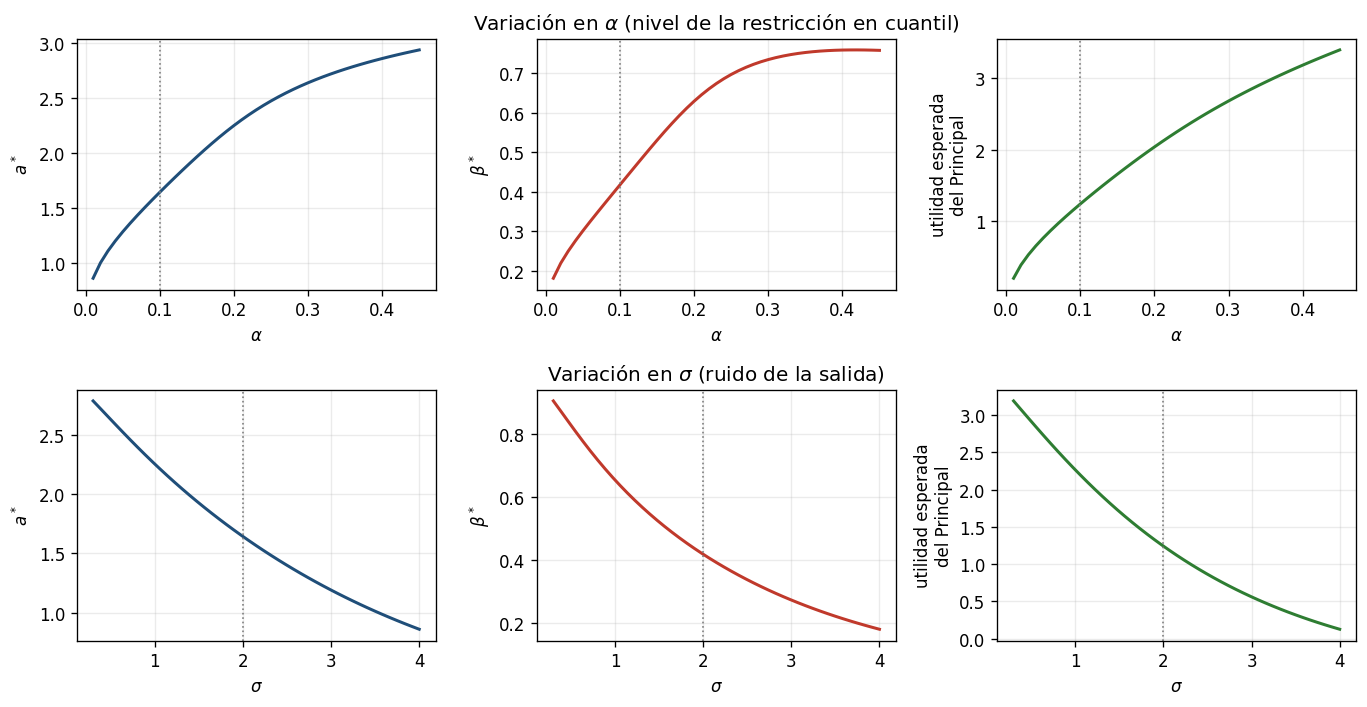

In [24]:
alphas = np.linspace(0.01, 0.45, 45)
sigmas = np.linspace(0.3, 4.0, 45)
Sa = np.array([[v] + [solve({**p, 'alpha': v}, n_a=700)[k] for k in ('a', 'beta', 'value')]
               for v in alphas])
Ss = np.array([[v] + [solve({**p, 'sigma': v}, n_a=700)[k] for k in ('a', 'beta', 'value')]
               for v in sigmas])

fig, ax = plt.subplots(2, 3, figsize=(11.5, 6))
etiquetas = ['$a^*$', r'$\beta^*$', 'utilidad esperada\ndel Principal']
for j, (lab, col) in enumerate(zip(etiquetas, [COL['main'], COL['alt'], COL['third']])):
    ax[0, j].plot(Sa[:, 0], Sa[:, j+1], color=col, lw=1.8)
    ax[0, j].axvline(p['alpha'], color=COL['grey'], ls=':', lw=1)
    ax[0, j].set_xlabel(r'$\alpha$'); ax[0, j].set_ylabel(lab)
    ax[1, j].plot(Ss[:, 0], Ss[:, j+1], color=col, lw=1.8)
    ax[1, j].axvline(p['sigma'], color=COL['grey'], ls=':', lw=1)
    ax[1, j].set_xlabel(r'$\sigma$'); ax[1, j].set_ylabel(lab)
ax[0, 1].set_title(r'Variación en $\alpha$ (nivel de la restricción en cuantil)')
ax[1, 1].set_title(r'Variación en $\sigma$ (ruido de la salida)')
fig.tight_layout(); plt.show()

Al aumentar $\alpha$ la restricción se relaja, pues el nivel de reserva debe alcanzarse en un
cuantil más alto, y crecen la acción implementada, la potencia de los incentivos y la utilidad
esperada del Principal. Al aumentar $\sigma$ la salida es más ruidosa: bajan $a^*$, $\beta^*$
y la utilidad esperada del Principal, que es el compromiso riesgo–incentivos clásico. Aquí
$\sigma$ actúa por dos vías simultáneas, la prima de riesgo $\tfrac\eta2\beta^2\sigma^2$ y el
desplazamiento $\phi_2=\sigma z_\alpha$ del punto de evaluación.

## 5. Figuras de la solución

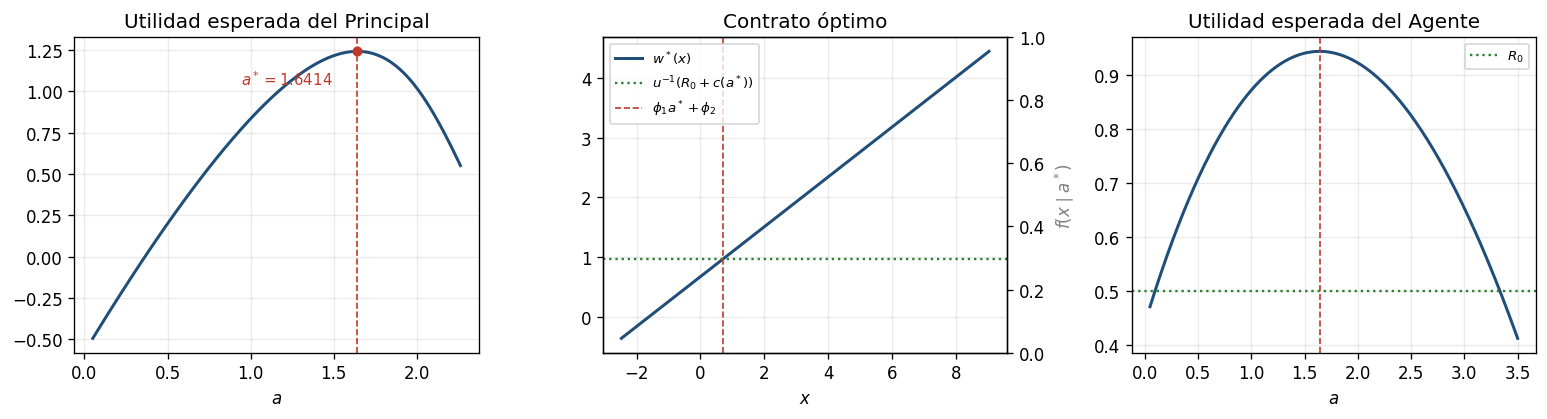

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

m = np.isfinite(sol['value_grid'])
ax[0].plot(sol['a_grid'][m], sol['value_grid'][m], color=COL['main'], lw=1.8)
ax[0].axvline(sol['a'], color=COL['alt'], ls='--', lw=1)
ax[0].plot([sol['a']], [sol['value']], 'o', color=COL['alt'], ms=5)
ax[0].annotate(rf"$a^*={sol['a']:.4f}$", (sol['a'], sol['value']),
               textcoords='offset points', xytext=(-70, -20), color=COL['alt'], fontsize=9)
ax[0].set_xlabel('$a$')
ax[0].set_title('Utilidad esperada del Principal')

lo = norm.ppf(.002, loc=p['kappa']*sol['a'], scale=p['sigma'])
hi = norm.ppf(.998, loc=p['kappa']*sol['a'], scale=p['sigma'])
x = np.linspace(lo, hi, 600)
pto = p['kappa']*sol['a'] + phi2(p)
ax[1].plot(x, sol['w0'] + sol['beta']*x, color=COL['main'], lw=1.8, label=r'$w^*(x)$')
ax[1].axhline(u_inv(p['R0'] + cost(sol['a'], p['theta']), p['eta']), color=COL['third'],
              ls=':', lw=1.4, label=r'$u^{-1}(R_0+c(a^*))$')
ax[1].axvline(pto, color=COL['alt'], ls='--', lw=1, label=r'$\phi_1 a^*+\phi_2$')
a2 = ax[1].twinx(); a2.grid(False)
a2.set_ylabel(r'$f(x\mid a^*)$', color=COL['grey'])
ax[1].set_xlabel('$x$')
ax[1].legend(loc='upper left', fontsize=8); ax[1].set_title('Contrato óptimo')

ag = np.linspace(p['a_min'], p['a_max'], 800)
ax[2].plot(ag, Phi(ag, sol['w0'], sol['beta'], p), color=COL['main'], lw=1.8)
ax[2].axvline(sol['a'], color=COL['alt'], ls='--', lw=1)
ax[2].axhline(p['R0'], color=COL['third'], ls=':', lw=1.4, label='$R_0$')
ax[2].set_xlabel('$a$')
ax[2].legend(fontsize=8); ax[2].set_title('Utilidad esperada del Agente')
fig.tight_layout(); plt.show()

Como $\mathcal X=\mathbb R$, ningún contrato afín no constante puede mantenerse no negativo,
de modo que en este ejemplo no cabe imponer $W\subseteq\mathbb R_+$. Con los valores óptimos,
$w^*(x)<0$ para $x<-1.606$, suceso de probabilidad aproximada $0.7\%$.

## 6. Más allá del contrato afín

Se fija una grilla $x_1<\dots<x_n$ sobre $\mathbb R$ y las variables pasan a ser los valores
$w_i=w(x_i)$, con $w$ lineal a trozos y extrapolación lineal en ambos extremos. La monotonía
y la concavidad son restricciones lineales. Las integrales se calculan con cuadratura de
Gauss--Hermite: con $x=\kappa a+\sigma\sqrt2\,t$,
$$\mathbb E[g(X)\mid a]=\int_{\mathbb R}g\bigl(\kappa a+\sigma\sqrt2\,t\bigr)\frac{e^{-t^2}}{\sqrt\pi}\,\mathrm dt
\approx\sum_j\frac{\omega_j}{\sqrt\pi}\,g\bigl(\kappa a+\sigma\sqrt2\,t_j\bigr),$$
y para la condición de primer orden se usa el score de la familia de localización,
$\partial_a\log f(x\mid a)=\kappa(x-\kappa a)/\sigma^2$. Aquí no existe reducción a una
dimensión, de modo que se recurre a un solver no lineal.

In [26]:
import warnings
from scipy.optimize import minimize
from scipy.special import roots_hermite
warnings.filterwarnings('ignore')

T, OM = roots_hermite(80); OM = OM/np.sqrt(np.pi)
Eq = lambda g, a: float(np.dot(OM, g(p['kappa']*a + p['sigma']*np.sqrt(2)*T)))

def dPhi_q(wf, a):
    s2 = p['sigma']**2
    return Eq(lambda x: u(wf(x), p['eta'])*p['kappa']*(x - p['kappa']*a)/s2, a) - p['theta']*a

# verificacion de la cuadratura contra las formulas cerradas del contrato afin
print('E[X]      cuadratura', Eq(lambda x: x, sol['a']), '| cerrado', p['kappa']*sol['a'])
print("Phi'(a*)  cuadratura", dPhi_q(lambda x: sol['w0'] + sol['beta']*x, sol['a']),
      '| cerrado', dPhi(sol['a'], sol['w0'], sol['beta'], p))

N = 22
XK = np.linspace(-6.0, 14.0, N)

def w_pl(z, wv):
    z = np.atleast_1d(np.asarray(z, float)); y = np.interp(z, XK, wv)
    sL = (wv[1]-wv[0])/(XK[1]-XK[0]); sR = (wv[-1]-wv[-2])/(XK[-1]-XK[-2])
    lo, hi = z < XK[0], z > XK[-1]
    y[lo] = wv[0] + sL*(z[lo]-XK[0]); y[hi] = wv[-1] + sR*(z[hi]-XK[-1])
    return y

Phi_pl = lambda wv, a: Eq(lambda x: u(w_pl(x, wv), p['eta']), a) - cost(a, p['theta'])
nobj   = lambda z: -(p['kappa']*z[-1] - Eq(lambda t: w_pl(t, z[:-1]), z[-1]))

base = [dict(type='eq',   fun=lambda z: dPhi_q(lambda t: w_pl(t, z[:-1]), z[-1])),
        dict(type='ineq', fun=lambda z: float(w_pl(p['kappa']*z[-1] + phi2(p), z[:-1])[0]
                                              - u_inv(p['R0']+cost(z[-1], p['theta']), p['eta']))),
        dict(type='ineq', fun=lambda z: np.diff(z[:-1])),
        dict(type='ineq', fun=lambda z: -np.diff(np.diff(z[:-1])/np.diff(XK)))]
extra = dict(type='ineq', fun=lambda z: Phi_pl(z[:-1], z[-1]) - p['R0'])

def resolver(cs):
    mejor = None
    for sc in (1.0, 0.9, 1.1):
        z0 = np.concatenate([sol['w0'] + sol['beta']*XK*sc, [sol['a']]])
        r = minimize(nobj, z0, method='SLSQP',
                     bounds=[(-60., 60.)]*N + [(p['a_min'], p['a_max'])],
                     constraints=cs, options=dict(maxiter=2000, ftol=1e-12))
        infact = max(abs(cs[0]['fun'](r.x)), max(0, -cs[1]['fun'](r.x)),
                     max(0, -min(cs[2]['fun'](r.x))), max(0, -min(cs[3]['fun'](r.x))),
                     max(0, -cs[4]['fun'](r.x)) if len(cs) > 4 else 0.0)
        if infact < 1e-7 and (mejor is None or -r.fun > mejor[0]):
            mejor = (-r.fun, r.x, infact)
    return mejor

v_q,  z_q,  _ = resolver(base)
v_qr, z_qr, _ = resolver(base + [extra])
wv_q,  a_q  = z_q[:-1],  z_q[-1]
wv_qr, a_qr = z_qr[:-1], z_qr[-1]

fmt = '{:<34}{:>12}{:>10}{:>10}{:>10}'
print()
print(fmt.format('', 'E[X-w(X)]', 'a', 'min w', 'Phi(a)'))
print(fmt.format('contrato afin', f"{sol['value']:.4f}", f"{sol['a']:.4f}", '',
                 f"{Phi(sol['a'], sol['w0'], sol['beta'], p):.4f}"))
print(fmt.format('lin. a trozos, solo cuantil', f'{v_q:.4f}', f'{a_q:.4f}',
                 f'{wv_q.min():.3f}', f'{Phi_pl(wv_q, a_q):.4f}'))
print(fmt.format('lin. a trozos, cuantil + PI', f'{v_qr:.4f}', f'{a_qr:.4f}',
                 f'{wv_qr.min():.3f}', f'{Phi_pl(wv_qr, a_qr):.4f}'))
print(fmt.format('primer optimo (salario cte.)', f"{fb['value']:.4f}", f"{fb['a']:.4f}", '', ''))
print(f"\nPI denota la participacion en esperanza Phi_w(a) >= R0 = {p['R0']}")

E[X]      cuadratura 3.282863864491509 | cerrado 3.282863864491509
Phi'(a*)  cuadratura -5.551115123125783e-17 | cerrado 0.0

                                     E[X-w(X)]         a     min w    Phi(a)
contrato afin                           1.2414    1.6414              0.9443
lin. a trozos, solo cuantil             3.6955    2.9566   -20.718    0.3096
lin. a trozos, cuantil + PI             3.4101    2.9204    -8.164    0.5000
primer optimo (salario cte.)            3.5921    3.0000                    

PI denota la participacion en esperanza Phi_w(a) >= R0 = 0.5


**Un hallazgo sobre la restricción en cuantil.** El contrato lineal a trozos que sólo
respeta la restricción en cuantil alcanza $3.6955$, valor que **supera al primer óptimo con
salario constante**. No es un artefacto numérico: el óptimo es estable frente al tamaño de la
caja de acotamiento, la infactibilidad es del orden de $10^{-15}$ y el valor no crece al
agrandar las cotas.

La explicación está en la última columna. Ese contrato deja al Agente con
$\Phi_w(a)=0.3096<R_0=0.5$: la restricción en cuantil mira **un solo punto**, y sobre un
soporte no acotado un contrato cóncavo y no decreciente puede desplomarse a la izquierda de
ese punto sin violarla. Aquí baja hasta $-20.7$. El Agente cumple la garantía probabilística
pero no participaría en valor esperado.

Es decir, sobre $\mathcal X=\mathbb R$ la participación en cuantil **no implica** la
participación en esperanza, y una clase de contratos suficientemente rica explota esa brecha.
En el ejemplo gamma esto no ocurría, porque el soporte $(0,\infty)$ junto con la no
negatividad del salario acotaban la caída por la izquierda.

Añadiendo explícitamente $\Phi_w(a)\ge R_0$ se recupera un resultado coherente: el valor baja
a $3.4101$, esa restricción queda activa con igualdad y el número sí cae por debajo del primer
óptimo. Ésa es la comparación que conviene reportar como cota inferior mejorada frente al
contrato afín.

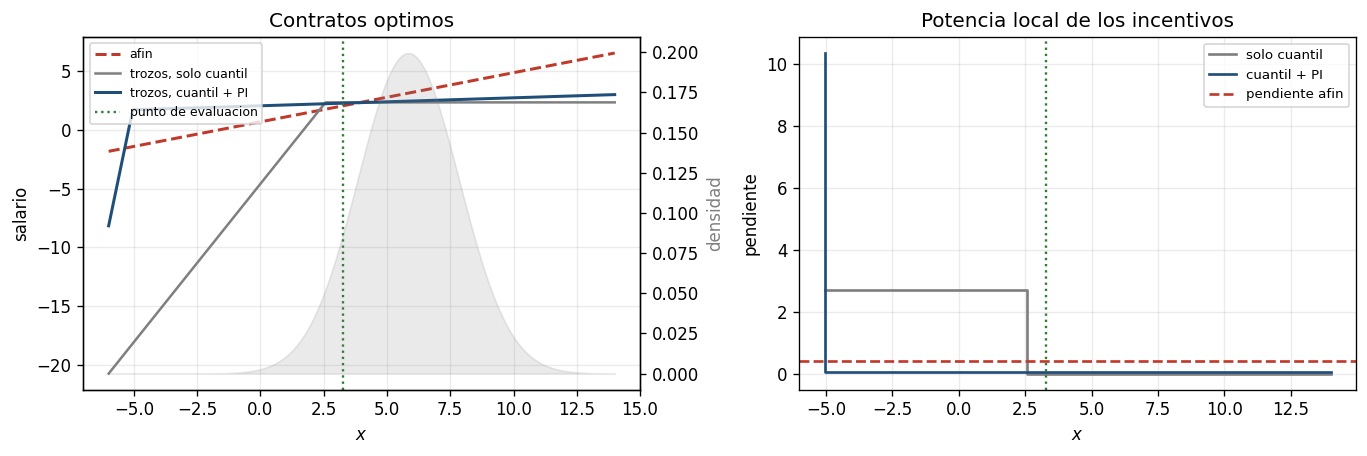

In [27]:
xg = np.linspace(-6, 14, 800)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax[0].plot(xg, sol['w0'] + sol['beta']*xg, color=COL['alt'], ls='--', lw=1.8, label='afin')
ax[0].plot(xg, w_pl(xg, wv_q), color=COL['grey'], lw=1.5, label='trozos, solo cuantil')
ax[0].plot(xg, w_pl(xg, wv_qr), color=COL['main'], lw=1.8, label='trozos, cuantil + PI')
ax[0].axvline(p['kappa']*a_qr + phi2(p), color=COL['third'], ls=':', lw=1.4,
              label='punto de evaluacion')
a2 = ax[0].twinx(); a2.grid(False)
a2.fill_between(xg, norm.pdf(xg, loc=p['kappa']*a_qr, scale=p['sigma']),
                color=COL['grey'], alpha=.16)
a2.set_ylabel('densidad', color=COL['grey'])
ax[0].set_xlabel('$x$'); ax[0].set_ylabel('salario')
ax[0].legend(loc='upper left', fontsize=7.5); ax[0].set_title('Contratos optimos')

for wv, col, lab in [(wv_q, COL['grey'], 'solo cuantil'), (wv_qr, COL['main'], 'cuantil + PI')]:
    ax[1].step(XK[1:], np.diff(w_pl(XK, wv))/np.diff(XK), where='pre', color=col, lw=1.6, label=lab)
ax[1].axhline(sol['beta'], color=COL['alt'], ls='--', lw=1.6, label='pendiente afin')
ax[1].axvline(p['kappa']*a_qr + phi2(p), color=COL['third'], ls=':', lw=1.4)
ax[1].set_xlabel('$x$'); ax[1].set_ylabel('pendiente')
ax[1].legend(fontsize=8); ax[1].set_title('Potencia local de los incentivos')
fig.tight_layout(); plt.show()